step1 - loading required libraries

step2 - load the data

step3 - data exploration

step4 - data visualisation

step5 - divide the data into train and testing

step6 - apply machine learning algorithms

In [1]:
# Step 1: import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

CRIM: per capita crime rate by town

ZN: proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS: proportion of non-retail business acres per town

CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX: nitric oxides concentration (parts per 10 million)

RM: average number of rooms per dwelling

AGE: proportion of owner-occupied units built prior to 1940

DIS: weighted distances to five Boston employment centres

RAD: index of accessibility to radial highways

TAX: full-value property-tax rate per ($10,000)

PTRATIO: pupil-teacher ratio by town

B: 1000(Bk - 0.63)^2 where Bk is the proportion of [people of African American descent] by town

LSTAT: % lower status of the population

MEDV: Median value of owner-occupied homes in $1000s (target variable)

In [2]:
#step2 - load the data
mydata = pd.read_csv("/content/Boston_HousingDataSet.xls")
mydata.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
#step3 - data exploration
mydata.shape

(506, 14)

In [4]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
## for checking null values
mydata.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [6]:
mydata.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


<Axes: xlabel='MEDV', ylabel='Count'>

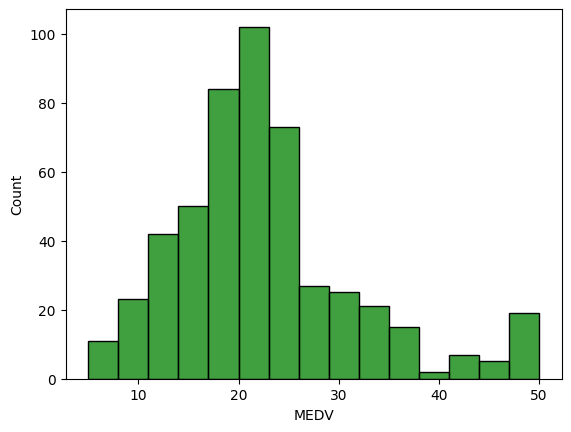

In [ ]:
#Step4 - data visualisation
#histogram of target variable
import seaborn as sns
sns.histplot(mydata['MEDV'], bins = 15 , color = 'green')

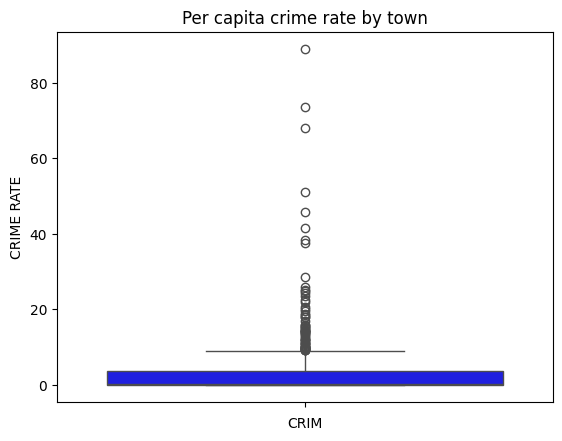

In [8]:
### boxplot crime rate

sns.boxplot(mydata["CRIM"], color = "blue")

plt.title("Per capita crime rate by town")
plt.xlabel("CRIM")
plt.ylabel("CRIME RATE")

plt.show()

Text(0, 0.5, 'Price in $1000s')

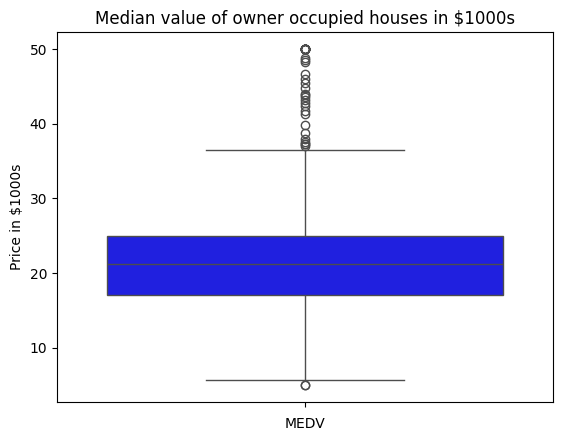

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(mydata['MEDV'], color= "blue")
plt.title("Median value of owner occupied houses in $1000s")
plt.xlabel("MEDV")
plt.ylabel("Price in $1000s")

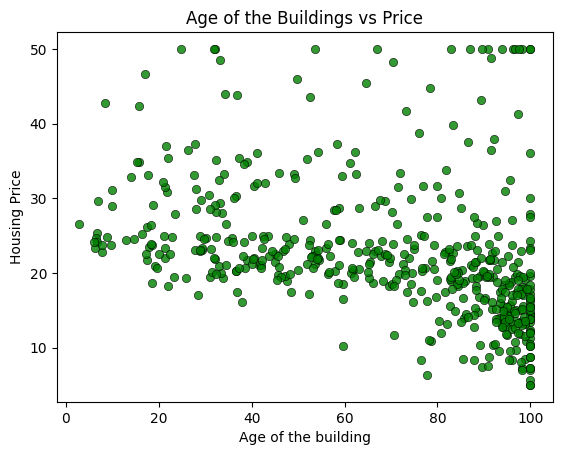

In [9]:
# SCATTER PLOTS

sns.scatterplot(x = "AGE", y = "MEDV", data = mydata,
                color = "green", edgecolor = "black", alpha = 0.8)

plt.title("Age of the Buildings vs Price")
plt.xlabel("Age of the building")
plt.ylabel("Housing Price")

plt.show()

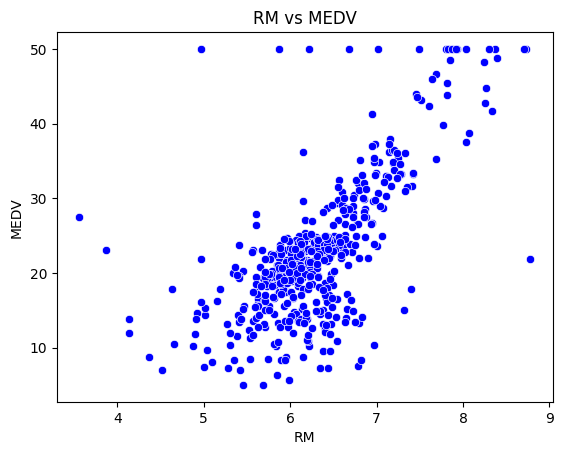

In [10]:
sns.scatterplot(x= 'RM', y= 'MEDV', data= mydata, color='blue')
plt.title('RM vs MEDV')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show()

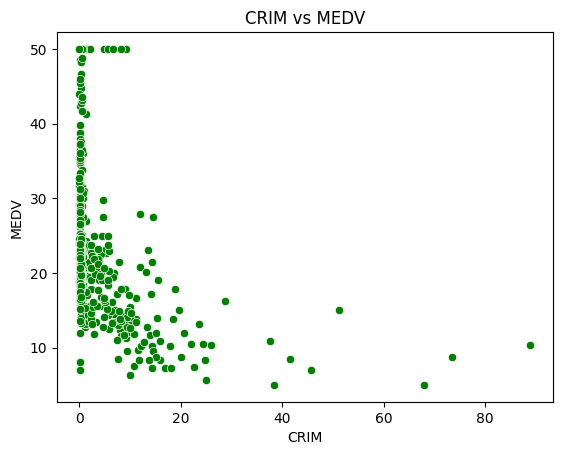

In [11]:
sns.scatterplot(x= 'CRIM', y= 'MEDV', data= mydata, color='green')
plt.title('CRIM vs MEDV')
plt.xlabel('CRIM')
plt.ylabel('MEDV')
plt.show()

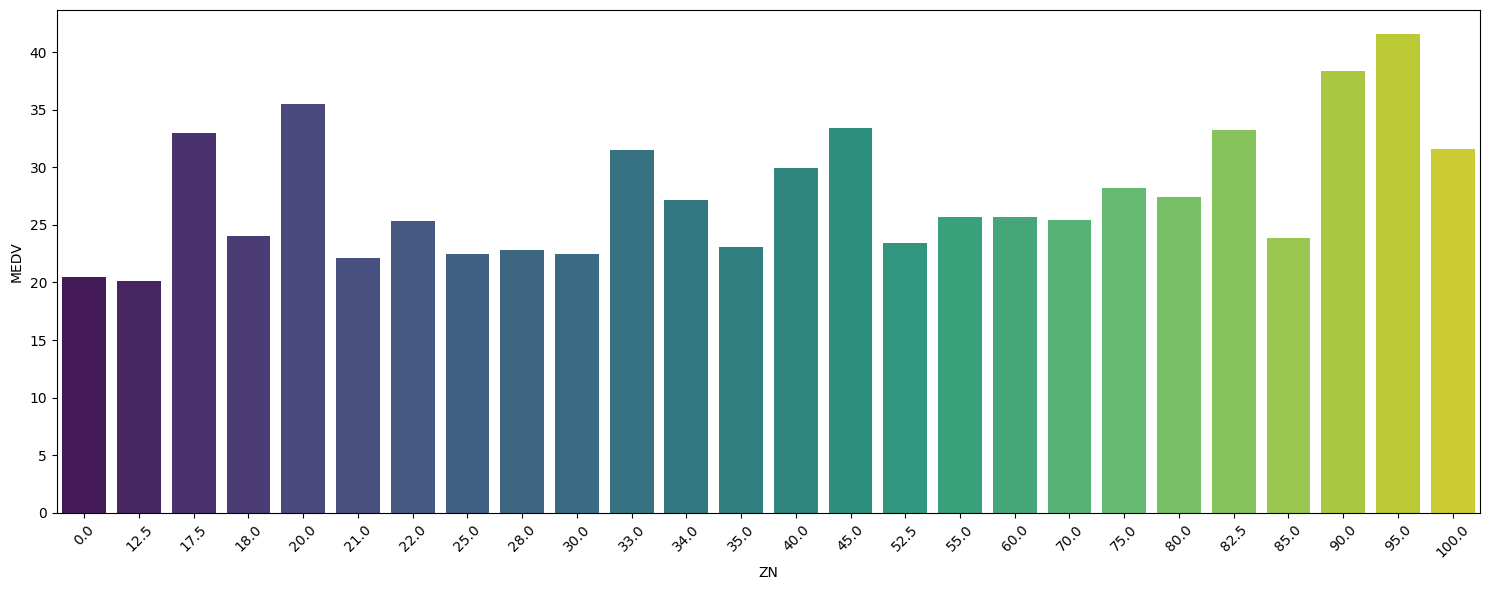

In [12]:
zn_medv_mean=mydata.groupby("ZN")["MEDV"].mean().reset_index()
figure_size = (15, 6)
plt.figure(figsize=figure_size)
sns.barplot(x= "ZN", y = "MEDV", data = zn_medv_mean, palette="viridis" )
plt.xticks(rotation=45)
plt.tight_layout()

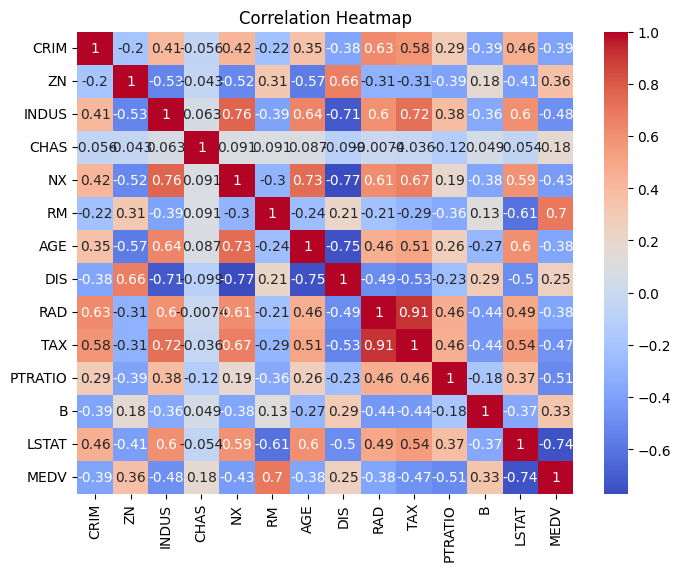

In [13]:
corr = mydata.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [14]:
X = mydata.drop(columns=["MEDV"])
y = mydata["MEDV"]

In [15]:
X.shape
X.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [16]:
y.shape

(506,)

In [17]:
###Step 5: divide the data into train and testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [18]:
X_train.shape

(354, 13)

In [19]:
y_train.shape

(354,)

In [20]:
###Step 6: apply machine learning algorithms

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_model = lr.fit(X_train, y_train)

In [21]:
lr_model.coef_

array([-1.33470103e-01,  3.58089136e-02,  4.95226452e-02,  3.11983512e+00,
       -1.54170609e+01,  4.05719923e+00, -1.08208352e-02, -1.38599824e+00,
        2.42727340e-01, -8.70223437e-03, -9.10685208e-01,  1.17941159e-02,
       -5.47113313e-01])

In [22]:
lr_model.intercept_

np.float64(31.63108403569261)

In [23]:
y_pred_lr = lr.predict(X_test)

In [24]:
from sklearn.metrics import root_mean_squared_error as rmse

rmse_lr = rmse(y_test, y_pred_lr)
rmse_lr

4.63868992617283

In [25]:
from sklearn.metrics import r2_score as r2

r2_lr = r2(y_test, y_pred_lr)
r2_lr

0.711226005748492

In [26]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()

lr_model = dtr.fit(X_train, y_train)

y_pred_dtr = dtr.predict(X_test)

rmse_dtr = rmse(y_test, y_pred_dtr)

r2_dtr = r2(y_test, y_pred_dtr)

In [27]:
r2_dtr

0.7412076238992364

In [28]:
rmse_dtr

4.3912892244341615

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

In [31]:
rf = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42
)

In [32]:
rf_model = rf.fit(X_train, y_train)

In [33]:
y_pred_rf = rf_model.predict(X_test)

In [37]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MSE: 9.619662013157892
RMSE: 3.1015579977098433
MAPE: 0.10856801497678763
R2 Score: 0.8708997131330258
